Installieren der scapy Bilbiothek

In [54]:
pip install scapy

Importieren der datei und bib

In [55]:
from scapy.all import rdpcap
import matplotlib.pyplot as plt

packets = rdpcap('http.pcapng')

Visualisieren wie viele Pakete aufgezeichnet worden sind

In [56]:
count = len(packets)
print(f"Es wurden {count} aufgezeichnet")

counter_UDP = 0
counter_TCP = 0

for packet in packets:
    if packet.haslayer('UDP'):
        counter_UDP += 1
    if packet.haslayer('TCP'):
        counter_TCP += 1

print(f"UDP: {counter_UDP}")
print(f"TCP: {counter_TCP}")

Es wurden 4438 aufgezeichnet
UDP: 198
TCP: 4240


Diagram mit Matplotlib erstellen

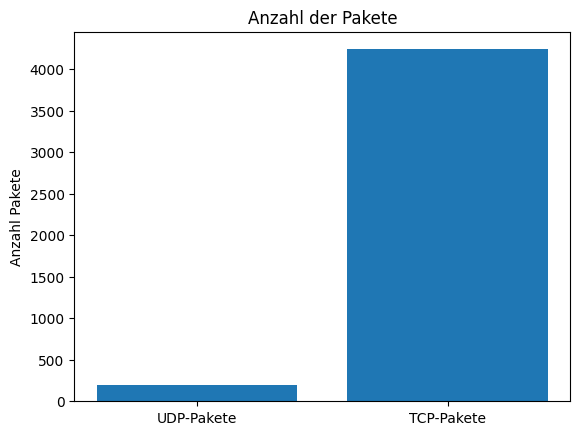

In [57]:
labels = ["UDP-Pakete"]
werte = [counter_UDP]
labels.append("TCP-Pakete")
werte.append(counter_TCP)

plt.bar(labels, werte)
plt.title("Anzahl der Pakete")
plt.ylabel("Anzahl Pakete")

plt.show()

Ausgabe im welchen Zeitraum es aufgezeichnet wurde

In [58]:
from datetime import datetime

start_dt = datetime.fromtimestamp(float(packets[0].time))
ende_dt = datetime.fromtimestamp(float(packets[-1].time))

print(f"Start: {start_dt.strftime('%Y-%m-%d %H:%M')}")
print(f"Ende: {ende_dt.strftime('%Y-%m-%d %H:%M')}")
print(f"Dauer: {ende_dt - start_dt}")

Start: 2012-11-07 18:06
Ende: 2012-11-07 18:06
Dauer: 0:00:38.381332


Wie viele Bytes wurden aufgezeichnet

In [59]:
total_bytes = sum(len(p) for p in packets)
print(f"Es wurden {total_bytes} Bytes aufgezeichnet")

Es wurden 3752809 Bytes aufgezeichnet


Wieviele unterschiedliche IPv4 Adressen wurden aufgezeichnet?

In [60]:
unique_ipv4_addresses = set()
ip_packets = 0
for packet in packets:
    if packet.haslayer('IP'):
        ip_packets += 1
        unique_ipv4_addresses.add(packet['IP'].src)
        unique_ipv4_addresses.add(packet['IP'].dst)

print(f"Es wurden {len(unique_ipv4_addresses)} unterschiedliche IPv4-Adressen aufgezeichnet.")

Es wurden 32 unterschiedliche IPv4-Adressen aufgezeichnet.


IP-Adressen auswertung Bar-Diagram

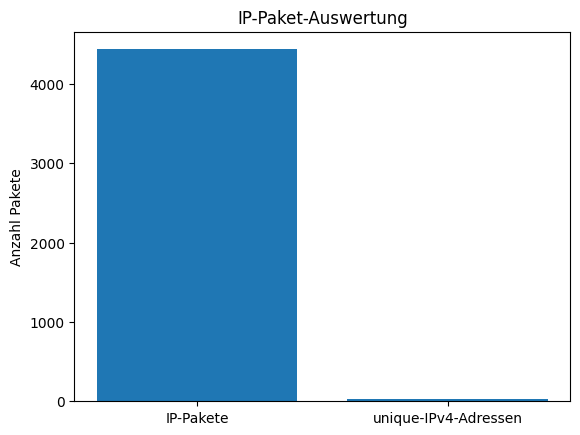

In [61]:
labels = ["IP-Pakete"]
werte = [ip_packets]
labels.append("unique-IPv4-Adressen")
werte.append(len(unique_ipv4_addresses))

plt.bar(labels, werte)
plt.title("IP-Paket-Auswertung")
plt.ylabel("Anzahl Pakete")

plt.show()

Wieviele HTTP-Requests sind aufgezeichnet worden?

In [62]:
http_requests = 0
http_packets = 0

for packet in packets:
    if packet.haslayer('TCP'):
        if packet['TCP'].dport == 80:
            http_packets += 1
            if packet.haslayer('Raw'):
                payload = packet['Raw'].load
                if (b'GET' in payload or
                    b'POST' in payload or
                    b'PUT' in payload or
                    b'DELETE' in payload):
                    http_requests += 1

print(f"Es wurden {http_requests} HTTP-Requests aufgezeichnet.")
print(f"Insgesamt gibt es {http_packets} HTTP Packete")

Es wurden 58 HTTP-Requests aufgezeichnet.
Insgesamt gibt es 399 HTTP Packete


Im vergleich als Bardiagram HTTP-Requests zu HTTP paketen

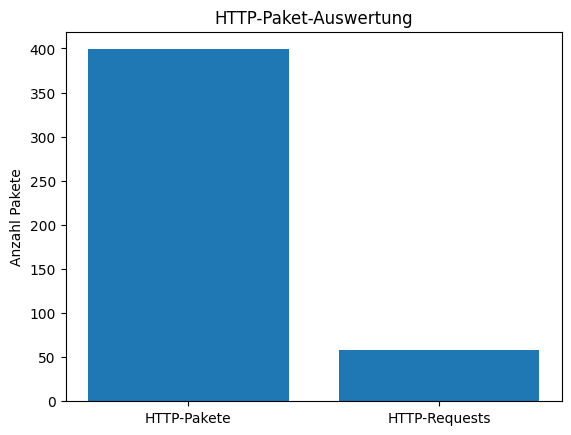

In [63]:
labels = ["HTTP-Pakete"]
werte = [http_packets]
labels.append("HTTP-Requests")
werte.append(http_requests)

plt.bar(labels, werte)
plt.title("HTTP-Paket-Auswertung")
plt.ylabel("Anzahl Pakete")

plt.show()

Wie viele TCP Flows gibt es?

In [64]:
unique_tcp_flows = set()
tcp_flows = 0
for packet in packets:
    if packet.haslayer('TCP'):
        tcp_flows += 1
        src_ip = packet['IP'].src if packet.haslayer('IP') else None
        dst_ip = packet['IP'].dst if packet.haslayer('IP') else None
        src_port = packet['TCP'].sport
        dst_port = packet['TCP'].dport

        flow_tuple = tuple(sorted(((src_ip, src_port), (dst_ip, dst_port))))
        unique_tcp_flows.add(flow_tuple)

print(f"Es wurden {len(unique_tcp_flows)} unterschiedliche TCP-Flows aufgezeichnet.")
print(f"Insgesamt gibt es {tcp_flows} TCP-Flows")

Es wurden 91 unterschiedliche TCP-Flows aufgezeichnet.
Insgesamt gibt es 4240 TCP-Flows


TCP Flows Bar-Diagram

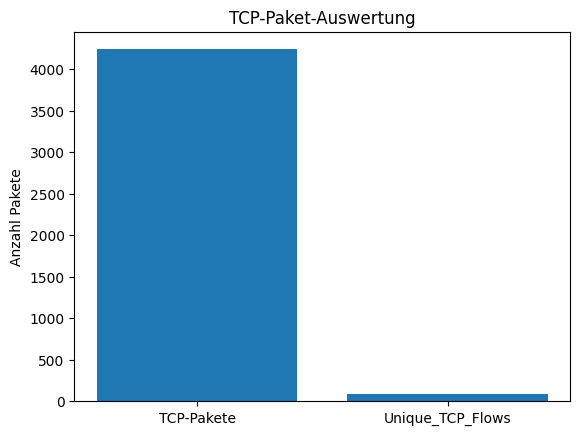

In [65]:
labels = ["TCP-Pakete"]
werte = [tcp_flows]
labels.append("Unique_TCP_Flows")
werte.append(len(unique_tcp_flows))

plt.bar(labels, werte)
plt.title("TCP-Paket-Auswertung")
plt.ylabel("Anzahl Pakete")

plt.show()

Von den TCP-Segmenten. Wie viele SYN, FIN, ACK und Datanpakete gibt es?

In [66]:
syn_packets = 0
fin_packets = 0
ack_packets = 0
data_packets = 0

for packet in packets:
    if packet.haslayer('TCP'):
        flags = packet['TCP'].flags
        if flags & 0x02:  # SYN flag (0x02)
            syn_packets += 1
        if flags & 0x01:  # FIN flag (0x01)
            fin_packets += 1
        if flags & 0x10:  # ACK flag (0x10)
            ack_packets += 1

        if packet.haslayer('Raw') or len(packet['TCP'].payload) > 0:
            data_packets += 1

print(f"SYN-Pakete: {syn_packets}")
print(f"FIN-Pakete: {fin_packets}")
print(f"ACK-Pakete: {ack_packets}")
print(f"Datenpakete: {data_packets}")

SYN-Pakete: 180
FIN-Pakete: 116
ACK-Pakete: 4147
Datenpakete: 2824


Bardiagram erstellen

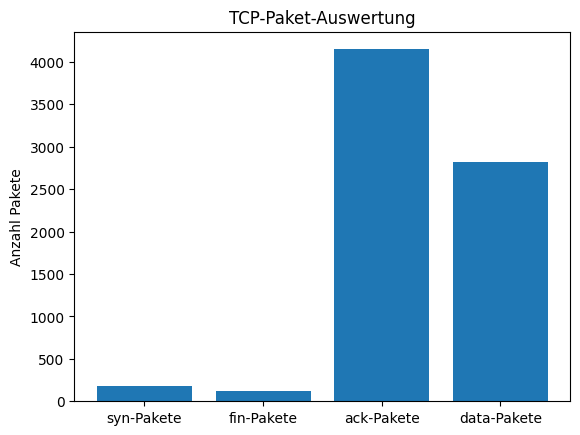

In [67]:
labels = ["syn-Pakete"]
werte = [syn_packets]
labels.append("fin-Pakete")
werte.append(fin_packets)
labels.append("ack-Pakete")
werte.append(ack_packets)
labels.append("data-Pakete")
werte.append(data_packets)

plt.bar(labels, werte)
plt.title("TCP-Paket-Auswertung")
plt.ylabel("Anzahl Pakete")

plt.show()